# Exploratory Data Analysis | Week 1

In [64]:
import os
import glob
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import geodatasets
from shapely.geometry import Point

In [95]:
file_list = glob.glob(r"C:\Users\zahir\CRMLSSold*.csv")
dataframes = [pd.read_csv(file) for file in file_list]
data = pd.concat(dataframes, ignore_index=True)

C:\Users\zahir\AppData\Local\Temp\ipykernel_22316\452635773.py:2: DtypeWarning: Columns (78,79) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in file_list]
C:\Users\zahir\AppData\Local\Temp\ipykernel_22316\452635773.py:2: DtypeWarning: Columns (2,36,39,56,74) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in file_list]
C:\Users\zahir\AppData\Local\Temp\ipykernel_22316\452635773.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in file_list]
C:\Users\zahir\AppData\Local\Temp\ipykernel_22316\452635773.py:2: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes = [pd.read_csv(file) for file in file_list]


In [23]:
data.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR
0,"Carpet,Wood",True,NaN,NaN,True,98000.0,556366533,michellefsellsoc@gmail.com,2022-02-25,95000.0,...,0.0,ABC Unified,92708,0.0,NaN,NaN,False,False,NaN,NaN
1,NaN,False,NaN,NaN,False,1200.0,556366530,dineshcalre@gmail.com,2022-02-19,1200.0,...,1.0,Apple Valley Unified,92308,0.0,43000.0,NaN,False,False,NaN,NaN
2,NaN,True,NaN,NaN,False,1100000.0,556366044,cindydavishomes@gmail.com,2022-04-15,1100000.0,...,1.0,Solana Beach,92075,370.0,NaN,NaN,False,False,NaN,NaN
3,NaN,True,NaN,NaN,False,2499999.0,556365765,bryanmeathe@gmail.com,2022-01-04,2499999.0,...,2.0,Carlsbad Unified,92008,140.0,13376.0,NaN,False,False,NaN,NaN
4,"Carpet,Tile",NaN,NaN,NaN,NaN,598888.0,556365290,steven@westsideres.com,2022-01-12,640000.0,...,1.0,Other,95111,300.0,2738.0,NaN,False,False,NaN,NaN


In [97]:
data = data.dropna(subset=['ClosePrice']) # 8 null values for Close 

In [98]:
data.shape

(794263, 82)

In [161]:
# We will focus on key variables for the analysis below
key_variables = [
    
    # target
    "ClosePrice", 
    
    # main charecteristics 
    "PropertyType",
    "PropertySubType",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LivingArea",         
    "LotSizeArea",        
    "YearBuilt",
    "Stories",             
    
    # amenities
    "PoolPrivateYN",
    "WaterfrontYN",
    "NewConstructionYN",
    "GarageSpaces",
    "BasementYN",
    
    # location
    "City",
    "PostalCode",
    "Latitude",
    "Longitude",
    
    # market
    "DaysOnMarket",
    "MlsStatus",
    "CloseDate",
    
    # tax and fees
    "TaxAnnualAmount",
    "AssociationFee"
]

In [162]:
df = data[key_variables]
df = df[(df["PropertyType"] == "Residential") & (df["PropertySubType"] == "SingleFamilyResidence")]
print("Data Shape:", df.shape)
df.head()

Data Shape: (399155, 23)


,ClosePrice,PropertyType,PropertySubType,BedroomsTotal,BathroomsTotalInteger,LivingArea,LotSizeArea,YearBuilt,Stories,PoolPrivateYN,...,BasementYN,City,PostalCode,Latitude,Longitude,DaysOnMarket,MlsStatus,CloseDate,TaxAnnualAmount,AssociationFee
3,2499999.0,Residential,SingleFamilyResidence,4.0,4.0,2645.0,13376.0,2016.0,NaN,False,...,NaN,Carlsbad,92008,33.147270,-117.340604,37.0,Closed,2022-01-04,NaN,140.0
6,640000.0,Residential,SingleFamilyResidence,3.0,3.0,2070.0,3397.0,2007.0,NaN,False,...,NaN,Lake Arrowhead,92352,34.235979,-117.202269,13.0,Closed,2022-01-10,NaN,0.0
7,438000.0,Residential,SingleFamilyResidence,3.0,2.0,1174.0,9900.0,1960.0,1.0,False,...,NaN,Fontana,92336,34.114130,-117.442493,3.0,Closed,2022-03-23,NaN,0.0
12,615000.0,Residential,SingleFamilyResidence,2.0,2.0,1996.0,6098.0,2005.0,NaN,True,...,NaN,Cathedral City,92234,33.783767,-116.447280,81.0,Closed,2022-01-10,NaN,195.0
14,399990.0,Residential,SingleFamilyResidence,3.0,2.0,1422.0,12197.0,2021.0,1.0,False,...,NaN,Paradise,95969,39.767729,-121.586400,63.0,Closed,2022-01-19,NaN,0.0


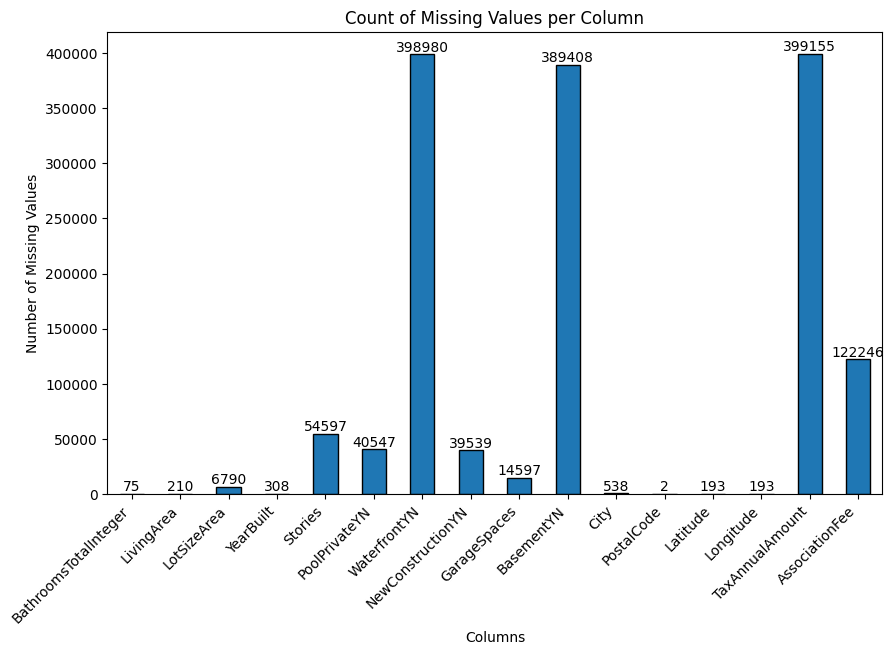

In [163]:
missing_counts = df.isna().sum()[df.isna().sum() > 0]
missing_percentages = ((df.isna().sum() / len(df)) * 100)[((df.isna().sum() / len(df)) * 100) > 0]

plt.figure(figsize=(10, 6))
missing_counts.plot(kind='bar', edgecolor='black')
plt.title('Count of Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right') 

for index, value in enumerate(missing_counts):
    plt.text(index, value + 0.1, str(value), ha='center', va='bottom')

In [164]:
print(df["WaterfrontYN"].unique(), '\n', df["TaxAnnualAmount"].unique(), '\n', df["AssociationFee"].unique())

[nan True] 
 [nan] 
 [ 140.     0.   195.  ... 1495.   265.5 3039. ]


At first, the extreme prescence of missing values with WaterfrontYN, TaxAnnualAmount, BasementYN, AssociationFee, and other key variables is alarming, so we dive deeper. WaterfrontYN and BasementYN have as many NaNs as they do because the "No" entries are listed as NaN, and "Yes" entries are listed as True. We will covert this to simply 0 and 1 values for easier computation, and notice we have no information for the TaxAnnualAmount so we will drop this column. Finally, the AssociationFee variable has a significant amount of missing values, but a distribution of expected values as well so we will avoid dropping the column at this moment.

Thorough data preprocessing including missing value handling will be expanded upon further in the coming week.

#### Examination of variable distribtions:

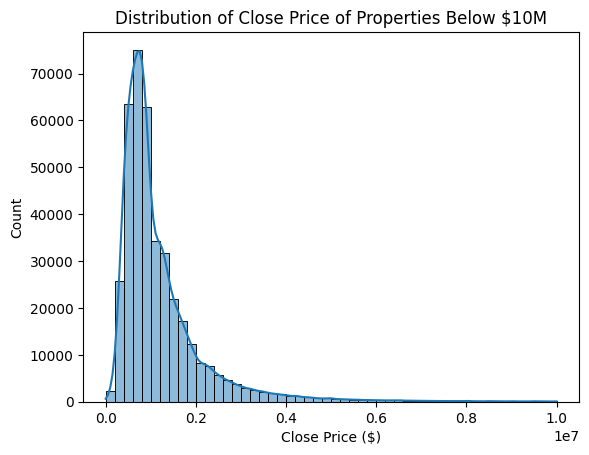

In [165]:
sns.histplot(df[df['ClosePrice'] <= 10000000]['ClosePrice'], kde=True, bins=50)
plt.title('Distribution of Close Price of Properties Below $10M')
plt.xlabel('Close Price ($)');

Distribution is heavily skewed by outliers, so we ignore properties above 10 million dollars.

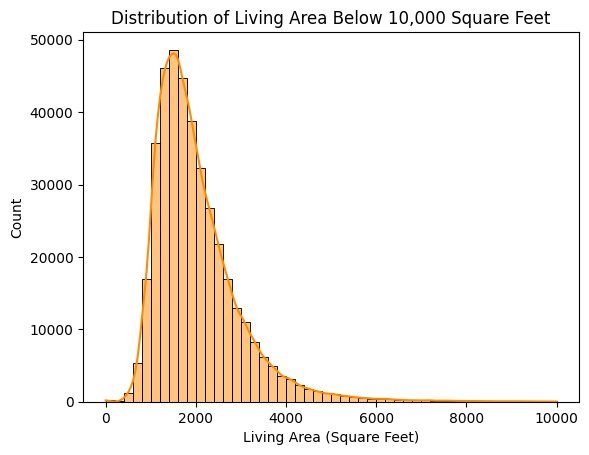

In [166]:
sns.histplot(df[df['LivingArea'] <= 1e4]['LivingArea'], kde=True, bins=50, color='darkorange')
plt.title('Distribution of Living Area Below 10,000 Square Feet')
plt.xlabel('Living Area (Square Feet)');

Distribution is heavily skewed by outliers, so we ignore properties with a living area above 10,000 sqaure feet.

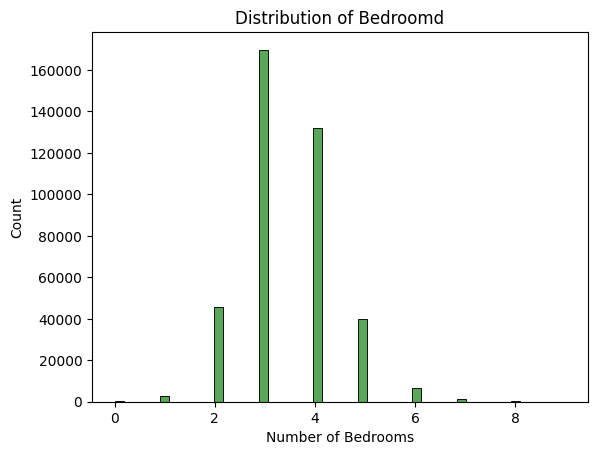

In [167]:
sns.histplot(df[df['BedroomsTotal'] < 10]['BedroomsTotal'], bins=50, color='forestgreen')
plt.title('Distribution of Bedroomd')
plt.xlabel('Number of Bedrooms');

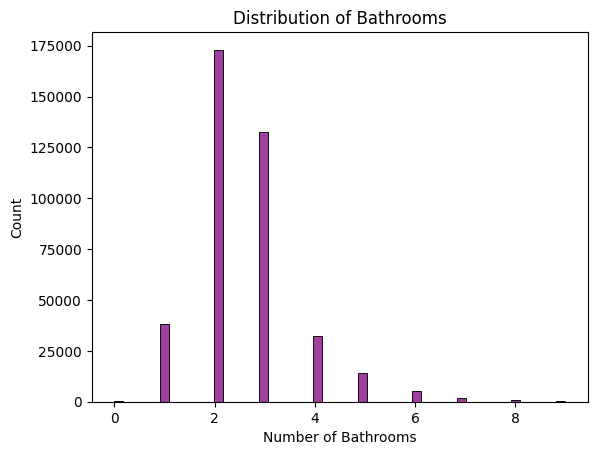

In [168]:
sns.histplot(df[df['BathroomsTotalInteger'] < 10]['BathroomsTotalInteger'], bins=50, color='purple')
plt.title('Distribution of Bathrooms')
plt.xlabel('Number of Bathrooms');

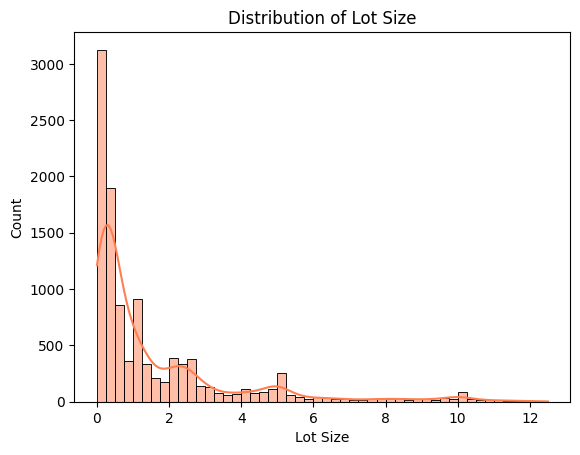

In [173]:
sns.histplot(df[df['LotSizeArea'] <= 12.5]['LotSizeArea'], kde=True, bins=50, color='coral')
plt.title('Distribution of Lot Size')
plt.xlabel('Lot Size');